In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter

In [2]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

In [7]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
global_SNP={}
for file in glob.glob('*assoc.txt.gz'):
    index1 = re.search('Eurasia',file).end()
    index2 = re.search('assoc.txt',file).start()
    element = file[index1+1:index2-1]
    df = pd.read_table(file)
    df['P'] = -(np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, df['chr'] == 2, df['chr'] == 3, df['chr'] == 4, df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    global_SNP[element] = df

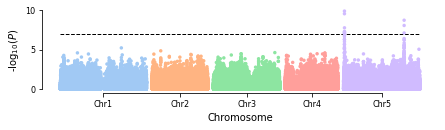

In [10]:
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
fig = plt.figure(figsize=(18*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=global_SNP['Mg25'],
                hue='chr',
                palette='pastel',
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(global_SNP['Mg25'])),
             xmin=min(global_SNP['Mg25']['position']),
             xmax=max(global_SNP['Mg25']['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("Fig2.pdf", format="pdf",bbox_inches="tight")